In [1]:
import os
import torch
from PIL import Image, ImageFilter
from diffusers.utils import load_image
from diffusers import AutoPipelineForInpainting, LCMScheduler

Multiple distributions found for package optimum. Picked distribution: optimum
c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


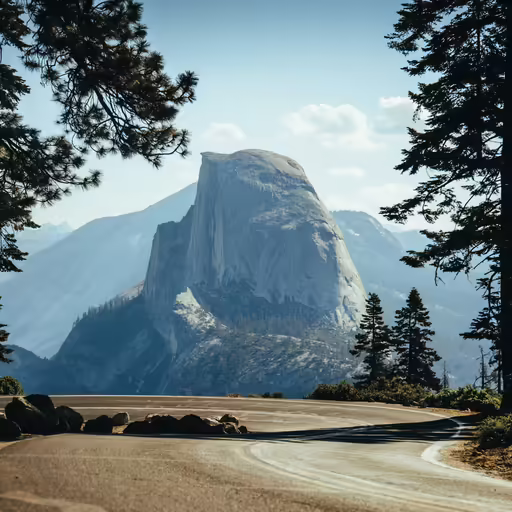

In [2]:
init_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png")
mask_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png")

init_image

In [3]:
prompt = "a black cat with glowing eyes, cute, adorable, cinematic lighting, highly detailed"
negative_prompt = "bad anatomy, deformed, ugly, disfigured, blurry, low quality"

pipe = AutoPipelineForInpainting.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-inpainting",
    torch_dtype=torch.float32,   # CPU-friendly
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\zeyad\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\zeyad\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\zeyad\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\zeyad\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to ra

The config attributes {'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/6 [00:00<?, ?it/s]

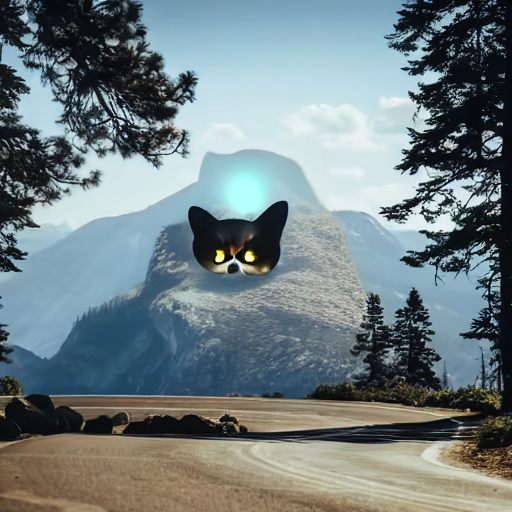

In [8]:
pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)
pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")

# These help with memory; they usually do not hurt CPU testability.
pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

generator = torch.Generator(device="cpu").manual_seed(42)

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=6,
    guidance_scale=4,   # try 1.0, 1.5, 2.0, then 4.0
    generator=generator,
).images[0]

image